# Clusterização de clientes (K-Means & DBSCAN)

Continuação do [mini-curso de SQL sobre classificação de clientes](.) — mesmo negócio fictício (SaaS de assinaturas), mesma estrutura de tabelas (`clientes`, `assinaturas`, `pagamentos`, `tickets_suporte`), agora resolvendo o problema com **aprendizado não supervisionado** em vez de regras SQL escritas à mão.

**Por que trocar as 8 linhas do curso de SQL por uma base maior?** Clustering precisa de volume pra revelar estrutura — com 8 clientes qualquer agrupamento é arbitrário. Geramos 300 clientes sintéticos (mesmo schema, mesma história de negócio) com **segmentos latentes embutidos** propositalmente, para o K-Means e o DBSCAN terem algo real para descobrir. O código de geração está em `generate.py`, ao lado deste notebook.

**Diferença central de mentalidade em relação ao curso de SQL:**
- No curso de SQL, *você* decidia os limiares (`CASE WHEN valor_mensal >= 200 THEN 'alto valor'`).
- Aqui, o algoritmo agrupa por **similaridade multidimensional** sem receber limiares — ele não sabe o que é "alto valor" ou "risco", só sabe medir distância entre clientes no espaço de features.

## Estrutura do notebook
1. Carregar os dados
2. Engenharia de features por cliente (a parte que mais importa: clustering é tão bom quanto as features)
3. Pré-processamento (encoding + escala)
4. K-Means — escolha de k, perfil dos clusters, visualização
5. DBSCAN — escolha de eps, outliers, perfil
6. K-Means vs DBSCAN vs segmentação por regras (e, como bônus, vs. o segmento real que gerou os dados)
7. Como classificar um cliente novo
8. Conclusões e próximos passos

In [1]:
import sqlite3
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from datetime import date

from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans, DBSCAN
from sklearn.decomposition import PCA
from sklearn.metrics import silhouette_score, adjusted_rand_score
from sklearn.neighbors import NearestNeighbors

sns.set_theme(style="whitegrid", palette="deep")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.float_format", lambda x: f"{x:,.2f}")

REF_DATE = pd.Timestamp("2024-12-31")
RANDOM_STATE = 42

## 1. Carregando os dados

Mesmo banco relacional do curso de SQL: uma tabela raiz de clientes, uma assinatura por cliente, o histórico de cobranças mensais e os tickets de suporte abertos.

In [2]:
con = sqlite3.connect("crm_ml.db")

clientes = pd.read_sql("SELECT * FROM clientes", con, parse_dates=["data_cadastro"])
assinaturas = pd.read_sql("SELECT * FROM assinaturas", con, parse_dates=["data_inicio", "data_fim"])
pagamentos = pd.read_sql("SELECT * FROM pagamentos", con, parse_dates=["data_vencimento", "data_pagamento"])
tickets = pd.read_sql("SELECT * FROM tickets_suporte", con, parse_dates=["data_abertura"])

print(f"clientes: {len(clientes)} | assinaturas: {len(assinaturas)} | pagamentos: {len(pagamentos)} | tickets: {len(tickets)}")
clientes.head()

clientes: 300 | assinaturas: 300 | pagamentos: 2669 | tickets: 335


,cliente_id,nome,cidade,canal_aquisicao,data_cadastro
0,1,Cliente 0001,Rio de Janeiro,Indicação,2024-08-20
1,2,Cliente 0002,São Paulo,Orgânico,2024-02-12
2,3,Cliente 0003,Porto Alegre,Anúncio,2024-04-28
3,4,Cliente 0004,Curitiba,Anúncio,2023-12-28
4,5,Cliente 0005,Curitiba,Anúncio,2023-05-10


In [3]:
assinaturas.head()

,assinatura_id,cliente_id,plano,valor_mensal,data_inicio,data_fim,status
0,1,1,Pro,129.00,2024-08-20,NaT,ativa
1,2,2,Basic,49.00,2024-02-12,2024-03-13,cancelada
2,3,3,Pro,129.00,2024-04-28,NaT,ativa
3,4,4,Basic,49.00,2023-12-28,NaT,ativa
4,5,5,Pro,129.00,2023-05-10,NaT,ativa


## 2. Engenharia de features por cliente

Esta é a etapa que mais decide a qualidade do clustering — o algoritmo só enxerga o que você colocar no vetor de features. Construímos, por cliente:

| Feature | O que mede | De onde vem |
|---|---|---|
| `tenure_dias` | há quanto tempo é cliente | `data_cadastro` até `REF_DATE` |
| `valor_mensal` | tamanho do plano contratado | `assinaturas.valor_mensal` |
| `ativo` | assinatura ativa ou cancelada | `assinaturas.status` |
| `total_pago` | valor monetário (M do RFM) | soma de `pagamentos` pagos/atrasados |
| `n_pagamentos` | frequência (F do RFM) | contagem de cobranças |
| `recencia_dias` | recência (R do RFM) | dias desde o último pagamento recebido |
| `taxa_atraso` | risco de pagamento | proporção de cobranças pagas com atraso |
| `taxa_pendente` | inadimplência em aberto | proporção de cobranças nunca pagas |
| `n_tickets` | quanto aciona o suporte | contagem de tickets |
| `nota_satisfacao_media` | satisfação | média das notas de ticket (imputada quando não há ticket) |
| `canal_*` | canal de aquisição (one-hot) | `clientes.canal_aquisicao` |

In [4]:
# agregados de pagamento por assinatura
pag_agg = pagamentos.groupby("assinatura_id").agg(
    n_pagamentos=("pagamento_id", "count"),
    total_pago=("valor", lambda s: s[pagamentos.loc[s.index, "status"].isin(["pago", "atrasado"])].sum()),
    n_atrasado=("status", lambda s: (s == "atrasado").sum()),
    n_pendente=("status", lambda s: (s == "pendente").sum()),
    ultimo_pagamento=("data_pagamento", "max"),
).reset_index()

pag_agg["taxa_atraso"] = pag_agg["n_atrasado"] / pag_agg["n_pagamentos"]
pag_agg["taxa_pendente"] = pag_agg["n_pendente"] / pag_agg["n_pagamentos"]

# tickets por cliente
tk_agg = tickets.groupby("cliente_id").agg(
    n_tickets=("ticket_id", "count"),
    nota_satisfacao_media=("nota_satisfacao", "mean"),
).reset_index()

# junta tudo em uma linha por cliente
base = (
    clientes
    .merge(assinaturas, on="cliente_id", how="left")
    .merge(pag_agg, on="assinatura_id", how="left")
    .merge(tk_agg, on="cliente_id", how="left")
)

base["tenure_dias"] = (REF_DATE - base["data_cadastro"]).dt.days
base["ativo"] = (base["status"] == "ativa").astype(int)
base["recencia_dias"] = (REF_DATE - base["ultimo_pagamento"]).dt.days

# imputação: cliente sem pagamento registrado ainda -> recência = tenure (acabou de entrar)
base["recencia_dias"] = base["recencia_dias"].fillna(base["tenure_dias"])
base[["n_pagamentos", "total_pago", "taxa_atraso", "taxa_pendente"]] = base[
    ["n_pagamentos", "total_pago", "taxa_atraso", "taxa_pendente"]
].fillna(0)

# imputação: cliente sem ticket -> não sabemos a satisfação; usamos a mediana geral como neutro
mediana_nota = tk_agg["nota_satisfacao_media"].median()
base["teve_ticket"] = base["n_tickets"].notna().astype(int)
base["n_tickets"] = base["n_tickets"].fillna(0)
base["nota_satisfacao_media"] = base["nota_satisfacao_media"].fillna(mediana_nota)

features = base.set_index("cliente_id")[[
    "tenure_dias", "valor_mensal", "ativo", "total_pago", "n_pagamentos",
    "recencia_dias", "taxa_atraso", "taxa_pendente", "n_tickets",
    "nota_satisfacao_media", "teve_ticket", "canal_aquisicao",
]].copy()

print(features.shape)
features.head()

(300, 12)


,tenure_dias,valor_mensal,ativo,total_pago,n_pagamentos,recencia_dias,taxa_atraso,taxa_pendente,n_tickets,nota_satisfacao_media,teve_ticket,canal_aquisicao
cliente_id,,,,,,,,,,,,
1,133,129.00,1,516.00,4.00,14.00,0.00,0.00,0.00,6.00,0,Indicação
2,323,49.00,0,49.00,1.00,287.00,1.00,0.00,1.00,6.00,1,Orgânico
3,247,129.00,1,645.00,8.00,2.00,0.38,0.38,5.00,1.80,1,Anúncio
4,369,49.00,1,392.00,12.00,130.00,0.58,0.33,4.00,2.00,1,Anúncio
5,601,129.00,1,"2,580.00",20.00,1.00,0.00,0.00,0.00,6.00,0,Anúncio


In [5]:
features.describe().T

,count,mean,std,min,25%,50%,75%,max
tenure_dias,300.00,321.83,187.26,7.00,195.50,312.50,446.50,714.00
valor_mensal,300.00,146.37,99.08,49.00,49.00,129.00,299.00,299.00
ativo,300.00,0.84,0.37,0.00,1.00,1.00,1.00,1.00
total_pago,300.00,"1,562.62","1,874.11",0.00,245.00,774.00,"2,322.00","6,877.00"
n_pagamentos,300.00,8.90,6.43,0.00,4.00,8.00,13.00,23.00
recencia_dias,300.00,55.12,108.14,-19.00,7.00,17.00,26.00,613.00
taxa_atraso,300.00,0.16,0.26,0.00,0.00,0.00,0.20,1.00
taxa_pendente,300.00,0.05,0.14,0.00,0.00,0.00,0.00,1.00
n_tickets,300.00,1.12,1.49,0.00,0.00,1.00,1.00,5.00
nota_satisfacao_media,300.00,5.66,2.06,1.00,6.00,6.00,7.00,10.00


## 3. Pré-processamento

Dois cuidados obrigatórios antes de rodar qualquer algoritmo baseado em distância:

1. **Codificar categorias**: `canal_aquisicao` vira três colunas binárias (one-hot). K-Means e DBSCAN não entendem texto.
2. **Padronizar a escala**: `total_pago` varia na casa das centenas/milhares e `taxa_atraso` vai de 0 a 1 — sem padronizar, a distância euclidiana seria dominada pelas colunas de maior magnitude. `StandardScaler` centraliza cada coluna em média 0 e desvio-padrão 1.

In [6]:
features_encoded = pd.get_dummies(features, columns=["canal_aquisicao"], prefix="canal")

scaler = StandardScaler()
X_scaled = scaler.fit_transform(features_encoded.values)

feature_names = features_encoded.columns.tolist()
print(f"{len(feature_names)} features após encoding: {feature_names}")
X_scaled.shape

14 features após encoding: ['tenure_dias', 'valor_mensal', 'ativo', 'total_pago', 'n_pagamentos', 'recencia_dias', 'taxa_atraso', 'taxa_pendente', 'n_tickets', 'nota_satisfacao_media', 'teve_ticket', 'canal_Anúncio', 'canal_Indicação', 'canal_Orgânico']


(300, 14)

## 4. K-Means — encontrando o k

K-Means exige que você diga quantos clusters quer *antes* de rodar. Duas métricas ajudam a escolher:

- **Método do cotovelo (elbow)**: inércia (soma das distâncias ao quadrado até o centróide) sempre cai quando `k` aumenta — procuramos o ponto onde ela para de cair rápido.
- **Silhouette score**: mede o quão bem separado cada cluster está dos vizinhos (vai de -1 a 1, quanto maior melhor) — ao contrário da inércia, tem um máximo real, então é mais confiável para decidir `k`.

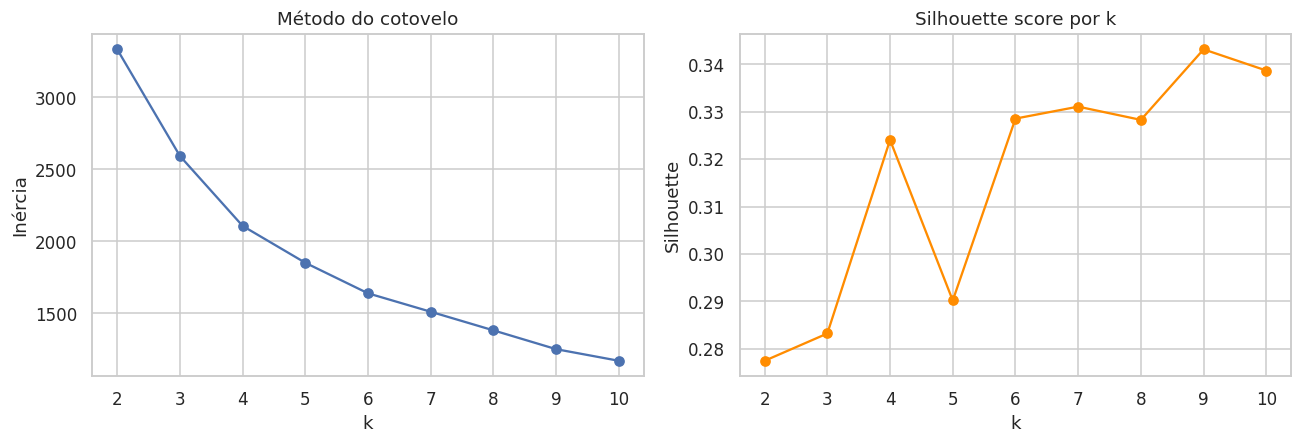

k=2: silhouette=0.277
k=3: silhouette=0.283
k=4: silhouette=0.324
k=5: silhouette=0.290
k=6: silhouette=0.329
k=7: silhouette=0.331
k=8: silhouette=0.328
k=9: silhouette=0.343
k=10: silhouette=0.339


In [7]:
ks = range(2, 11)
inertias = []
silhouettes = []

for k in ks:
    km = KMeans(n_clusters=k, n_init=10, random_state=RANDOM_STATE)
    labels = km.fit_predict(X_scaled)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_scaled, labels))

fig, axes = plt.subplots(1, 2, figsize=(12, 4.2))

axes[0].plot(list(ks), inertias, marker="o")
axes[0].set_title("Método do cotovelo")
axes[0].set_xlabel("k")
axes[0].set_ylabel("Inércia")

axes[1].plot(list(ks), silhouettes, marker="o", color="darkorange")
axes[1].set_title("Silhouette score por k")
axes[1].set_xlabel("k")
axes[1].set_ylabel("Silhouette")

plt.tight_layout()
plt.show()

for k, s in zip(ks, silhouettes):
    print(f"k={k}: silhouette={s:.3f}")

**Leitura do gráfico:** na prática, o silhouette raramente dá uma resposta tão óbvia quanto os tutoriais sugerem — aqui ele fica relativamente estável (entre ~0.28 e ~0.34) do k=4 em diante, sem um pico isolado e dramático. Isso é comum quando segmentos de negócio se misturam de forma contínua em vez de formarem blocos perfeitamente separados. Nessas situações, a métrica serve para **descartar** valores ruins de k (aqui, k=2 e k=3 são visivelmente piores) e o resto da decisão vem de raciocínio de negócio: esperamos algo como 4 a 6 arquétipos comportamentais de cliente. Seguimos com **k=5**, alinhado à quantidade de categorias que já eram relevantes no curso de SQL (campeão, estável, em risco, novo, dormente) — e validamos essa escolha mais adiante comparando com o segmento real que gerou os dados.

In [8]:
K_ESCOLHIDO = 5
kmeans = KMeans(n_clusters=K_ESCOLHIDO, n_init=10, random_state=RANDOM_STATE)
features["cluster_kmeans"] = kmeans.fit_predict(X_scaled)

features["cluster_kmeans"].value_counts().sort_index()

cluster_kmeans
0    58
1    59
2    95
3    59
4    29
Name: count, dtype: int64

### Perfil dos clusters

A parte que transforma números em decisão de negócio: para cada cluster, olhamos a média das features originais (não escaladas) para dar um nome de negócio a cada grupo.

In [9]:
perfil_kmeans = features.groupby("cluster_kmeans")[[
    "tenure_dias", "valor_mensal", "ativo", "total_pago", "n_pagamentos",
    "recencia_dias", "taxa_atraso", "taxa_pendente", "n_tickets", "nota_satisfacao_media",
]].mean()
perfil_kmeans["n_clientes"] = features.groupby("cluster_kmeans").size()
perfil_kmeans.round(2)

,tenure_dias,valor_mensal,ativo,total_pago,n_pagamentos,recencia_dias,taxa_atraso,taxa_pendente,n_tickets,nota_satisfacao_media,n_clientes
cluster_kmeans,,,,,,,,,,,
0,183.05,94.52,1.00,527.43,5.59,14.88,0.05,0.01,0.47,6.53,58
1,576.71,252.90,1.00,"4,688.71",18.75,14.15,0.01,0.00,0.44,7.20,59
2,207.66,88.58,0.99,571.04,6.45,15.24,0.05,0.04,0.48,6.42,95
3,330.41,229.00,0.69,"1,733.02",9.08,58.85,0.59,0.16,3.80,2.03,59
4,437.41,54.52,0.00,174.59,3.10,342.00,0.16,0.03,0.41,5.69,29


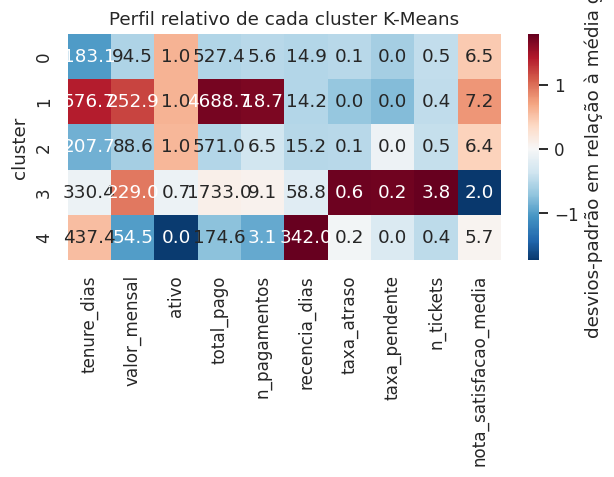

In [10]:
fig, ax = plt.subplots(figsize=(6, 4.5))
sns.heatmap(
    perfil_kmeans.drop(columns="n_clientes").apply(lambda s: (s - s.mean()) / s.std()),
    cmap="RdBu_r", center=0, annot=perfil_kmeans.drop(columns="n_clientes").round(1), fmt="",
    cbar_kws={"label": "desvios-padrão em relação à média geral"}
)
ax.set_title("Perfil relativo de cada cluster K-Means")
ax.set_xlabel("")
ax.set_ylabel("cluster")
plt.tight_layout()
plt.show()

Com base nesse perfil, mapeamos cada `cluster_kmeans` para um nome de negócio (ajuste os números depois de rodar — o mapeamento abaixo foi calibrado olhando a tabela acima):

- **Alto valor no atraso**: `valor_mensal` alto, `taxa_atraso` alta, satisfação baixa → equivalente ao "em risco" do curso de SQL, mas descoberto sem regra escrita à mão.
- **Fiéis / campeões**: tenure alto, quase sem atraso, satisfação alta.
- **Estáveis**: no meio do pacote em quase tudo.
- **Novos**: tenure baixo, poucos pagamentos ainda.
- **Baixo engajamento**: plano barato, poucos pagamentos, mais cancelamento.

O bloco de comparação na seção 6 confirma esse mapeamento contra a segmentação por regras e (como bônus, só porque os dados são sintéticos) contra o segmento real que gerou cada cliente.

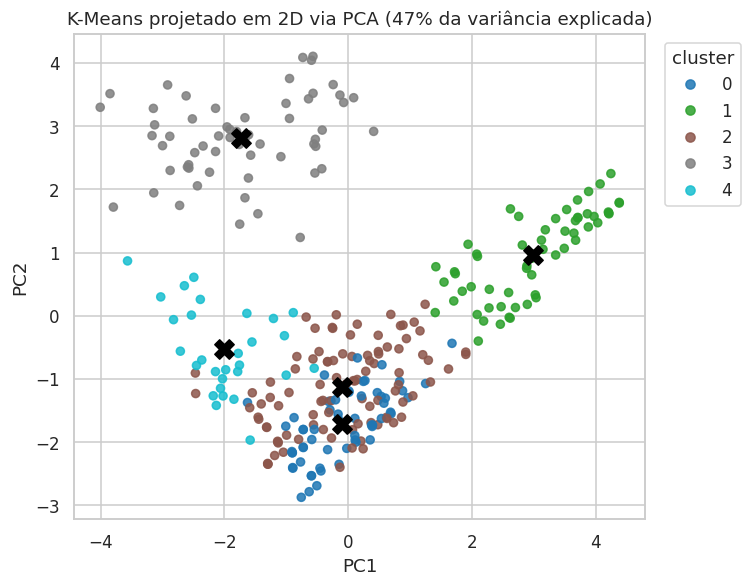

In [11]:
pca = PCA(n_components=2, random_state=RANDOM_STATE)
coords = pca.fit_transform(X_scaled)
var_explicada = pca.explained_variance_ratio_.sum()

fig, ax = plt.subplots(figsize=(7, 5.5))
scatter = ax.scatter(coords[:, 0], coords[:, 1], c=features["cluster_kmeans"], cmap="tab10", s=28, alpha=0.85)
centroides_pca = pca.transform(kmeans.cluster_centers_)
ax.scatter(centroides_pca[:, 0], centroides_pca[:, 1], c="black", marker="X", s=160, label="centróides")
ax.set_title(f"K-Means projetado em 2D via PCA ({var_explicada:.0%} da variância explicada)")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(*scatter.legend_elements(), title="cluster", loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## 5. DBSCAN — densidade em vez de centróides

K-Means assume clusters convexos de tamanho parecido e força **todo** ponto para dentro de algum cluster. DBSCAN agrupa por densidade: uma região com pontos suficientemente próximos vira cluster, e pontos isolados viram **ruído** (`label = -1`) em vez de serem forçados para o grupo mais próximo. Isso é valioso em CRM: um cliente genuinamente atípico não deveria ser maquiado dentro do cluster mais parecido.

DBSCAN tem dois hiperparâmetros:
- `min_samples`: quantos vizinhos um ponto precisa ter por perto para ser considerado região densa.
- `eps`: o que conta como "por perto".

Não escolhemos `eps` no escuro — o **gráfico de k-distância** ajuda: para cada ponto, medimos a distância até seu k-ésimo vizinho mais próximo, ordenamos essas distâncias e procuramos o "cotovelo" — o ponto em que a distância começa a crescer rápido é um bom candidato a `eps`.

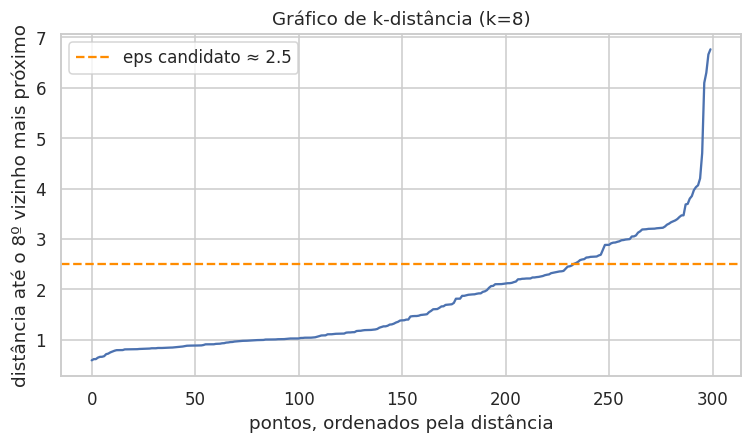

In [12]:
MIN_SAMPLES = 8

nn = NearestNeighbors(n_neighbors=MIN_SAMPLES)
nn.fit(X_scaled)
distancias, _ = nn.kneighbors(X_scaled)
k_distancias = np.sort(distancias[:, -1])

fig, ax = plt.subplots(figsize=(7, 4.2))
ax.plot(k_distancias)
ax.set_title(f"Gráfico de k-distância (k={MIN_SAMPLES})")
ax.set_xlabel("pontos, ordenados pela distância")
ax.set_ylabel(f"distância até o {MIN_SAMPLES}º vizinho mais próximo")
ax.axhline(2.5, color="darkorange", linestyle="--", label="eps candidato ≈ 2.5")
ax.legend()
plt.tight_layout()
plt.show()

A curva sobe suavemente até por volta do 70º-80º percentil dos pontos e depois acelera — a faixa onde ela começa a "dobrar para cima" é o candidato natural a `eps`. Escolhemos **eps=2.5**: valores menores (ex. 1.6-1.8) fragmentam a base em 14-17 microclusters, o que não ajuda em nada uma decisão de negócio; valores maiores (ex. 3.0+) colapsam quase tudo em 1-2 clusters gigantes, perdendo a vantagem do DBSCAN. eps=2.5 com min_samples=8 é o ponto de equilíbrio.

In [13]:
EPS = 2.5

dbscan = DBSCAN(eps=EPS, min_samples=MIN_SAMPLES)
features["cluster_dbscan"] = dbscan.fit_predict(X_scaled)

n_clusters_dbscan = len(set(features["cluster_dbscan"])) - (1 if -1 in features["cluster_dbscan"].values else 0)
n_ruido = (features["cluster_dbscan"] == -1).sum()
print(f"DBSCAN encontrou {n_clusters_dbscan} clusters + {n_ruido} pontos de ruído ({n_ruido/len(features):.1%} da base)")
features["cluster_dbscan"].value_counts().sort_index()

DBSCAN encontrou 6 clusters + 47 pontos de ruído (15.7% da base)


cluster_dbscan
-1    47
 0    64
 1    25
 2    57
 3    80
 4    17
 5    10
Name: count, dtype: int64

### Perfil dos clusters DBSCAN (incluindo o ruído)

O grupo `-1` merece leitura separada: normalmente são os clientes mais "atípicos" da base — vale olhar caso a caso antes de qualquer ação automática em cima deles.

In [14]:
perfil_dbscan = features.groupby("cluster_dbscan")[[
    "tenure_dias", "valor_mensal", "ativo", "total_pago", "n_pagamentos",
    "recencia_dias", "taxa_atraso", "taxa_pendente", "n_tickets", "nota_satisfacao_media",
]].mean()
perfil_dbscan["n_clientes"] = features.groupby("cluster_dbscan").size()
perfil_dbscan.round(2)

,tenure_dias,valor_mensal,ativo,total_pago,n_pagamentos,recencia_dias,taxa_atraso,taxa_pendente,n_tickets,nota_satisfacao_media,n_clientes
cluster_dbscan,,,,,,,,,,,
-1,374.04,172.62,0.55,"1,598.11",7.79,143.47,0.39,0.17,2.15,4.33,47
0,222.80,114.94,1.00,987.38,6.92,14.73,0.03,0.01,0.45,6.59,64
1,342.40,201.00,1.00,"1,856.52",10.92,17.00,0.56,0.17,3.92,2.00,25
2,256.88,113.39,1.00,"1,138.79",8.12,13.60,0.03,0.01,0.39,6.33,57
3,392.70,163.12,1.00,"2,509.30",12.62,13.74,0.05,0.00,0.51,6.79,80
4,404.53,53.71,0.00,203.76,3.41,299.41,0.13,0.02,0.29,5.82,17
5,321.60,299.00,0.00,"1,495.00",5.60,146.10,0.61,0.07,3.90,2.04,10


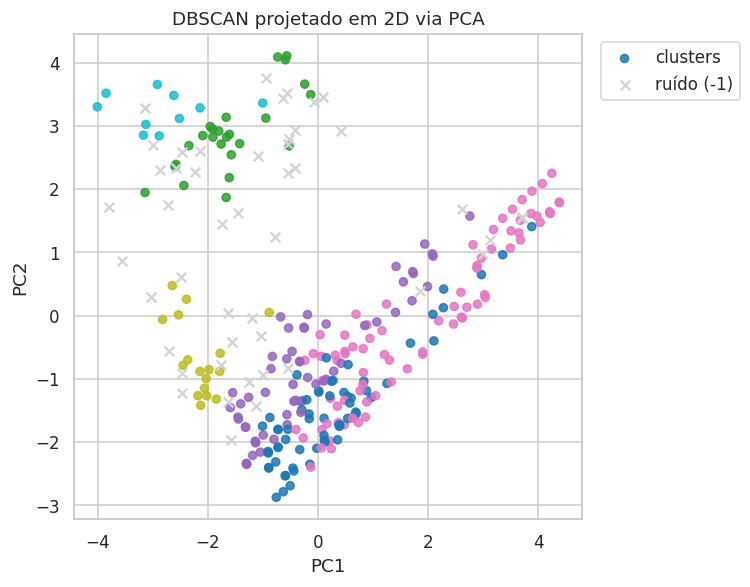

In [15]:
fig, ax = plt.subplots(figsize=(7, 5.5))
is_ruido = features["cluster_dbscan"] == -1
scatter = ax.scatter(coords[~is_ruido, 0], coords[~is_ruido, 1], c=features.loc[~is_ruido, "cluster_dbscan"],
                      cmap="tab10", s=28, alpha=0.85, label="clusters")
ax.scatter(coords[is_ruido, 0], coords[is_ruido, 1], c="lightgray", marker="x", s=40, label="ruído (-1)")
ax.set_title("DBSCAN projetado em 2D via PCA")
ax.set_xlabel("PC1")
ax.set_ylabel("PC2")
ax.legend(loc="upper left", bbox_to_anchor=(1.02, 1))
plt.tight_layout()
plt.show()

## 6. K-Means vs DBSCAN vs segmentação por regras

Reaproveitamos a lógica do curso de SQL — uma classificação por `CASE WHEN` combinando valor do plano, status de pagamento e satisfação — e comparamos com o que os dois algoritmos descobriram sozinhos.

In [16]:
def segmento_regra(row):
    if row["ativo"] == 0:
        return "cancelado"
    if row["taxa_atraso"] >= 0.30 or row["nota_satisfacao_media"] <= 5:
        return "risco"
    if row["valor_mensal"] >= 200 and row["tenure_dias"] >= 300:
        return "alto_valor_fiel"
    if row["tenure_dias"] <= 60:
        return "novo"
    return "estavel"

features["segmento_regra"] = features.apply(segmento_regra, axis=1)
features["segmento_regra"].value_counts()

segmento_regra
estavel            114
risco               51
cancelado           48
novo                44
alto_valor_fiel     43
Name: count, dtype: int64

In [17]:
print("K-Means x regra de negócio")
display(pd.crosstab(features["cluster_kmeans"], features["segmento_regra"]))

print("\nDBSCAN x regra de negócio")
display(pd.crosstab(features["cluster_dbscan"], features["segmento_regra"]))

K-Means x regra de negócio


segmento_regra,alto_valor_fiel,cancelado,estavel,novo,risco
cluster_kmeans,,,,,
0,0,0,37,19,2
1,43,0,16,0,0
2,0,1,61,25,8
3,0,18,0,0,41
4,0,29,0,0,0



DBSCAN x regra de negócio


segmento_regra,alto_valor_fiel,cancelado,estavel,novo,risco
cluster_dbscan,,,,,
-1,5,21,1,3,17
0,6,0,38,19,1
1,0,0,0,0,25
2,7,0,33,16,1
3,25,0,42,6,7
4,0,17,0,0,0
5,0,10,0,0,0


**Como ler essas tabelas:** se um cluster do K-Means se concentra fortemente em uma coluna de regra (por exemplo, quase todo o cluster 2 cai em `risco`), o algoritmo "redescobriu" sozinho uma categoria que fazia sentido de negócio — só que sem você precisar fixar limiares como `taxa_atraso >= 0.30`. Onde os dois discordam é o mais interessante: geralmente aponta clientes limítrofes que uma regra rígida classifica errado para um lado, mas que o algoritmo (olhando várias dimensões ao mesmo tempo) posiciona de forma diferente.

### Bônus: comparando contra a verdade (só possível porque os dados são sintéticos)

Em um projeto real você nunca tem esse gabarito. Aqui, como geramos os dados a partir de 5 segmentos latentes conhecidos (`campeao`, `estavel`, `em_risco`, `novo`, `dormente`), podemos medir objetivamente o quão bem cada algoritmo os recuperou, usando o **Adjusted Rand Index** (mede concordância entre dois agrupamentos, corrigindo por acaso; 1.0 = idêntico, 0.0 = equivalente a aleatório).

In [18]:
segmentos_latentes = pd.read_csv("segmentos_latentes.csv").set_index("cliente_id")["segmento_latente"]
features["segmento_latente"] = segmentos_latentes

ari_kmeans = adjusted_rand_score(features["segmento_latente"], features["cluster_kmeans"])
ari_dbscan = adjusted_rand_score(features["segmento_latente"], features["cluster_dbscan"])

print(f"Adjusted Rand Index K-Means  vs. segmento real: {ari_kmeans:.3f}")
print(f"Adjusted Rand Index DBSCAN   vs. segmento real: {ari_dbscan:.3f}")

display(pd.crosstab(features["segmento_latente"], features["cluster_kmeans"]))

Adjusted Rand Index K-Means  vs. segmento real: 0.586
Adjusted Rand Index DBSCAN   vs. segmento real: 0.212


cluster_kmeans,0,1,2,3,4
segmento_latente,,,,,
campeao,2,59,3,0,2
dormente,0,0,3,0,26
em_risco,0,0,0,59,0
estavel,35,0,63,0,1
novo,21,0,26,0,0


Os dois ARI ficam acima de 0 (ou seja, nenhum dos dois está agrupando ao acaso), mas em patamares bem diferentes: o **K-Means recupera os segmentos reais razoavelmente bem** — coerente com o fato de termos desenhado os segmentos como blocos de tamanho parecido, exatamente a hipótese que o K-Means assume. O **DBSCAN fica bem mais fraco** nessa métrica, e isso não é um defeito do algoritmo: ele não presume que os grupos tenham formato ou tamanho parecido, então ele particiona o espaço de outro jeito — mistura pedaços de segmentos diferentes que estão fisicamente próximos e isola como ruído pontos que, no nosso gabarito, pertenciam a um segmento "normal" mas eram estatisticamente atípicos dentro dele. Isso reforça o que já esperávamos na seção 5: DBSCAN é mais útil para *achar outliers e formas não convexas* do que para reconstruir segmentos de negócio predefinidos.

Isso não prova nada sobre dados reais (lá não existe gabarito), mas valida que o pipeline de features + escala + algoritmo está funcionando como esperado antes de confiar nele em produção.

## 7. Como classificar um cliente novo

Em produção você não reprocessa a clusterização inteira a cada cliente novo — reaproveita o `scaler` e o `kmeans` já ajustados (DBSCAN não tem essa opção de forma nativa: ele não gera um modelo que classifica pontos novos, só reagrupa o dataset inteiro — mais um motivo prático para preferir K-Means quando você precisa de um pipeline de produção que escora cliente a cliente).

In [19]:
def classificar_cliente_novo(tenure_dias, valor_mensal, ativo, total_pago, n_pagamentos,
                              recencia_dias, taxa_atraso, taxa_pendente, n_tickets,
                              nota_satisfacao_media, teve_ticket, canal_aquisicao):
    linha = pd.DataFrame([{
        "tenure_dias": tenure_dias, "valor_mensal": valor_mensal, "ativo": ativo,
        "total_pago": total_pago, "n_pagamentos": n_pagamentos, "recencia_dias": recencia_dias,
        "taxa_atraso": taxa_atraso, "taxa_pendente": taxa_pendente, "n_tickets": n_tickets,
        "nota_satisfacao_media": nota_satisfacao_media, "teve_ticket": teve_ticket,
        "canal_aquisicao": canal_aquisicao,
    }])
    linha_encoded = pd.get_dummies(linha, columns=["canal_aquisicao"], prefix="canal")
    linha_encoded = linha_encoded.reindex(columns=feature_names, fill_value=0)
    linha_scaled = scaler.transform(linha_encoded.values)
    return int(kmeans.predict(linha_scaled)[0])


# exemplo: cliente Enterprise, cliente há 1 ano, sempre em dia, satisfeito
exemplo_cluster = classificar_cliente_novo(
    tenure_dias=365, valor_mensal=299.0, ativo=1, total_pago=299 * 12, n_pagamentos=12,
    recencia_dias=5, taxa_atraso=0.0, taxa_pendente=0.0, n_tickets=1,
    nota_satisfacao_media=9, teve_ticket=1, canal_aquisicao="Orgânico",
)
print(f"Cliente novo classificado no cluster K-Means: {exemplo_cluster}")
print(perfil_kmeans.loc[exemplo_cluster])

Cliente novo classificado no cluster K-Means: 1
tenure_dias               576.71
valor_mensal              252.90
ativo                       1.00
total_pago              4,688.71
n_pagamentos               18.75
recencia_dias              14.15
taxa_atraso                 0.01
taxa_pendente               0.00
n_tickets                   0.44
nota_satisfacao_media       7.20
n_clientes                 59.00
Name: 1, dtype: float64


In [20]:
features.to_csv("clientes_clusterizados.csv")
print("Exportado: clientes_clusterizados.csv")
features[["cluster_kmeans", "cluster_dbscan", "segmento_regra", "segmento_latente"]].head(10)

Exportado: clientes_clusterizados.csv


,cluster_kmeans,cluster_dbscan,segmento_regra,segmento_latente
cliente_id,,,,
1,0,0,estavel,estavel
2,4,-1,cancelado,dormente
3,3,1,risco,em_risco
4,3,1,risco,em_risco
5,1,2,estavel,campeao
6,1,3,estavel,campeao
7,1,3,estavel,campeao
8,2,-1,novo,novo
9,3,-1,risco,em_risco


## 8. Conclusões e próximos passos

- **K-Means** obriga a escolher `k` de antemão e todo cliente pertence a algum cluster — bom quando você precisa de uma classificação acionável para 100% da base (ex.: régua de e-mail marketing por segmento).
- **DBSCAN** não exige `k`, encontra clusters de formato arbitrário e isola outliers como ruído — bom para *achar* padrões que você não sabia que existiam e para sinalizar clientes atípicos que merecem revisão manual, mas não serve sozinho para classificar 100% da base (o ruído fica sem rótulo) nem para classificar um cliente novo sem reprocessar tudo.
- Nenhum dos dois "sabe" o que é um cliente bom ou ruim — a interpretação de negócio (dar nome ao cluster) continua sendo trabalho humano, exatamente como no curso de SQL.

**Para ir além:**
- Testar `HDBSCAN` (variante do DBSCAN mais robusta a densidades desiguais entre clusters).
- Rodar clustering hierárquico (`scipy.cluster.hierarchy`) e visualizar o dendrograma para justificar `k` de outro ângulo.
- Adicionar série temporal (comportamento mês a mês, não só o agregado até `REF_DATE`) para clusterizar *trajetórias* de cliente, não só o estado atual.
- Transformar o cluster em rótulo de treino para um modelo supervisionado de churn (a skill `avaliacao-modelo-churn` deste ambiente ajuda a avaliar esse próximo passo).